# Task B — From R to Python: Translating Statistical Analysis
> **BAFAD Accelerated Research Track · Fall 2026**

This task bridges your STAT 270 R work with the Python data science ecosystem used in AI research.
You will reproduce three analyses from Assignment 1 — originally written in R using `dplyr` and `ggplot2` — in Python using `pandas` and `matplotlib`.

**Reference file:** `task_b_r_original.R` (in this folder) — contains the complete R code you are translating.

**Data:** `../data/flights.csv` and `../data/airports.csv`

**Submission:** Push your completed notebook to your fork of the starter repository and paste the repo URL into the Canvas assignment.

## Setup

Run this cell first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NAVY = '#021B3A'
BLUE = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

flights  = pd.read_csv('../data/flights.csv')
airports = pd.read_csv('../data/airports.csv')

print(f'flights:  {flights.shape[0]:,} rows × {flights.shape[1]} columns')
print(f'airports: {airports.shape[0]} rows × {airports.shape[1]} columns')
flights.head(3)

flights:  1,000 rows × 19 columns
airports: 35 rows × 8 columns


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,7,27,669,645,24,1083,1059,45,F9,4502,N772AA,LGA,MKE,254,2294,6,45,2013-07-27 06:00:00
1,2013,7,11,693,715,-22,1334,1356,-9,YV,8275,N414EF,LGA,MCO,401,3254,7,15,2013-07-11 07:00:00
2,2013,3,3,1466,1415,51,2071,2020,58,F9,6396,N348AE,JFK,PHX,365,3196,14,15,2013-03-03 14:00:00


---
## Question 2 — Frequency Tables and Proportions (10 pts)

### Part A (4 pts)
Compute the **number of flights** and the **proportion of all flights** operated by each carrier.
Display the result sorted from most to least flights.

**R equivalent:**
```r
flights |> count(carrier, sort = TRUE) |> mutate(prop = n / sum(n))
```

*Python hints:*
- `flights['carrier'].value_counts()` gives counts sorted descending.
- Divide by `len(flights)` to get proportions.
- Build a `pd.DataFrame` with columns `carrier`, `n`, `prop`.

In [3]:
carrier_counts = flights['carrier'].value_counts()

# Create summary table
carrier_summary = pd.DataFrame({
    'carrier': carrier_counts.index,
    'n': carrier_counts.values,
    'prop': carrier_counts.values / len(flights)
})

carrier_summary

,carrier,n,prop
0,F9,74,0.074
1,B6,72,0.072
2,US,71,0.071
3,UA,68,0.068
4,DL,67,0.067
5,MQ,66,0.066
6,VX,64,0.064
7,9E,63,0.063
8,YV,61,0.061
9,EV,61,0.061


**Answer** — Which carrier operated the most flights? What was its approximate share?
Frontier Airlines (F9) operated the most flights, with approximately 7.4% of the total flights.

### Part B (6 pts)
Compute the **proportion of flights that arrived late** (`arr_delay > 0`) for each carrier,
sorted from highest to lowest late-arrival rate.

**R equivalent:**
```r
flights |> group_by(carrier) |>
  summarise(late_rate = mean(arr_delay > 0, na.rm = TRUE)) |>
  arrange(desc(late_rate))
```

*Python hints:*
- `(flights['arr_delay'] > 0)` produces a boolean Series; take `.mean()` per group.
- Use `groupby('carrier').apply(...)` or `groupby('carrier')['arr_delay'].agg(...)`.

In [4]:
late_arrivals = (
    flights.groupby('carrier')['arr_delay']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
    .reset_index(name='late_prop')
)

late_arrivals

,carrier,late_prop
0,AS,0.735849
1,UA,0.705882
2,YV,0.704918
3,US,0.704225
4,HA,0.689655
5,VX,0.687500
6,DL,0.686567
7,AA,0.672414
8,9E,0.650794
9,EV,0.639344


**Answer** — Which carrier had the worst on-time arrival record?
Alaska Airlines (AS) had the worst on-time arrival record, with approximately 73.6% of its flights arriving late (arr_delay > 0)

---
## Question 3 — Histogram, Density, and Shape (15 pts)

### Part A (7 pts)
Create a **density histogram** of `dep_delay`, restricted to flights where `dep_delay` is between −60 and 180 minutes.
Overlay a kernel density estimate (KDE) curve.

- Use `NAVY` (`'#021B3A'`) for the histogram bars.
- Use `BLUE` (`'#0EA5E9'`) for the KDE line.
- Apply `plt.style.use('seaborn-v0_8-whitegrid')` or `plt.rcParams` for a clean background.

**R equivalent:**
```r
flights_filtered |> ggplot(aes(x = dep_delay)) +
  geom_histogram(aes(y = after_stat(density)), fill='#021B3A') +
  geom_density(colour='#0EA5E9') + theme_bw()
```

*Python hints:*
- Filter: `df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)]`
- `ax.hist(..., density=True)` gives a density-normalised histogram.
- `from scipy.stats import gaussian_kde` or `df_filtered['dep_delay'].plot.kde(ax=ax)` for the curve.

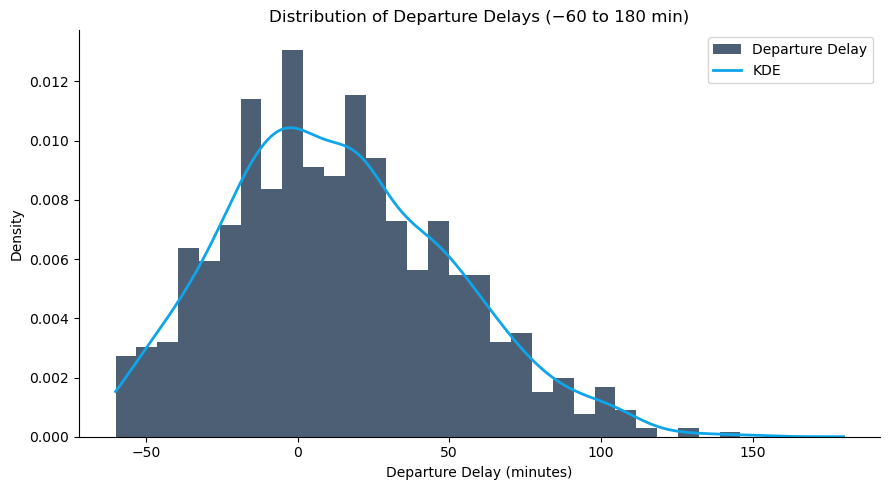

In [5]:
from scipy.stats import gaussian_kde

df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

# Remove missing values
dep_delay = df_filtered['dep_delay'].dropna()

# Density histogram
ax.hist(
    dep_delay,
    bins=30,
    density=True,
    color=NAVY,
    alpha=0.7,
    label='Departure Delay'
)

# Calculate KDE
kde = gaussian_kde(dep_delay)

# Generate values from -60 to 180 for KDE curve
x = np.linspace(-60, 180, 500)

# Overlay KDE curve
ax.plot(
    x,
    kde(x),
    color=BLUE,
    linewidth=2,
    label='KDE'
)

# Add legend
ax.legend()

# Labels and title
ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Departure Delays (−60 to 180 min)')
plt.tight_layout()
plt.show()

### Part B (8 pts)
Compute and report the **median** and **IQR** of `dep_delay` (same filtered range), then describe the distribution in complete sentences addressing: shape, modality, centre, and spread.

In [6]:
# Compute median departure delay
median_delay = df_filtered['dep_delay'].median()

# Compute IQR
q1 = df_filtered['dep_delay'].quantile(0.25)
q3 = df_filtered['dep_delay'].quantile(0.75)
iqr_delay = q3 - q1

print(f'Median departure delay: {median_delay:.1f} min')
print(f'IQR of departure delay: {iqr_delay:.1f} min')

Median departure delay: 11.0 min
IQR of departure delay: 53.8 min


**Answer** — Shape, modality, centre, spread:
The departure-delay distribution is unimodal and right-skewed, with most flights concentrated around smaller delays and a tail extending toward longer positive delays. The center of the distribution is a median departure delay of approximately 11.0 minutes. The IQR is approximately 53.8 minutes, indicating that the middle 50% of departure delays are spread across a range of about 54 minutes.


---
## Question 4 — Grouped Summaries by Origin Airport (15 pts)

### Part A (7 pts)
For each of the three origin airports (EWR, JFK, LGA), compute the **mean, median, standard deviation, and IQR** of `arr_delay`.
Display the results as a summary table.

**R equivalent:**
```r
flights |> group_by(origin) |>
  summarise(mean_arr=mean(arr_delay,na.rm=T), median_arr=median(...), sd_arr=sd(...), iqr_arr=IQR(...))
```

*Python hints:*
- Use `flights.groupby('origin')['arr_delay'].agg(['mean','median','std'])` and add IQR via `lambda`.
- For IQR: `from scipy.stats import iqr` or `lambda x: x.quantile(0.75) - x.quantile(0.25)`.

In [7]:
from scipy.stats import iqr as scipy_iqr

# Compute summary statistics by origin airport
origin_summary = (
    flights.groupby('origin')['arr_delay']
    .agg(
        mean='mean',
        median='median',
        std='std',
        IQR=lambda x: scipy_iqr(x, nan_policy='omit')
    )
    .round(2)
)

origin_summary

,mean,median,std,IQR
origin,,,,
EWR,16.34,15.0,43.27,56.0
JFK,20.06,19.0,43.27,58.0
LGA,15.10,15.0,42.42,57.5


### Part B (8 pts)
Based on your table, answer in complete sentences:
1. Which airport has the **highest mean** arrival delay? Lowest?
2. For each airport, is the mean **higher or lower** than the median? What does this imply about the shape of each delay distribution?
3. Which airport shows the **greatest spread** (use SD to support your answer)?

**Answer:**

1. JFK has the highest mean arrival delay at approximately 20.06 minutes, while LGA has the lowest mean arrival delay at approximately 15.10 minutes.

2. The mean is higher than the median for all three airports: EWR (16.34 vs. 15.0), JFK (20.06 vs. 19.0), and LGA (15.10 vs. 15.0). This suggests that the arrival-delay distributions are right-skewed, although the skew appears very slight for LGA based on the mean-median comparison.

3. EWR shows the greatest spread, with a standard deviation of approximately 43.27 minutes. JFK is extremely close at 43.27 minutes, while LGA has the smallest standard deviation at approximately 42.42 minutes.


---
## Reflection (not graded — but read before Task C)

Take 5 minutes to jot down:
- What was the hardest part of translating R to Python?
- What Python feature did you find most useful or surprising?
- How do `pandas` and `dplyr` differ in their approach to grouped operations?

You will expand on this in `task-c/reflection.md`.

In [ ]:
The most difficult part of translating R to Python was adjusting to the differences syntax, especially for grouped summaries and data manipulation. In R, `dplyr` uses functions such as `group_by()` and `summarise()`, while Python uses `pandas` methods such as `groupby()` and `agg()`.

The Python feature I found most useful was the ability to use Boolean expressions directly in calculations. 
    
For example, `(flights['arr_delay'] > 0).mean()` provides a simple way to calculate the proportion of flights that arrived late because `True` and `False` behave like 1 and 0 when calculating the mean.

`pandas` and `dplyr` both follow the split-apply-combine approach, but they organize grouped operations differently. `dplyr` uses a pipeline of verbs such as `group_by()` followed by `summarise()`, while `pandas` creates a `GroupBy` object and then applies methods such as `.mean()`, `.agg()`, or `.apply()` to that object.
